In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

datapath = r"/home/karth-local/projects/retailrocket-upliftstudy/rr_dataset/"

In [2]:
events_df = pd.read_csv(datapath + "events.csv")
category_tree_df = pd.read_csv(datapath + "category_tree.csv")
item_properties_part1_df = pd.read_csv(datapath + "item_properties_part1.csv")
item_properties_part2_df = pd.read_csv(datapath + "item_properties_part2.csv")

In [3]:
events_df.columns

Index(['timestamp', 'visitorid', 'event', 'itemid', 'transactionid'], dtype='object')

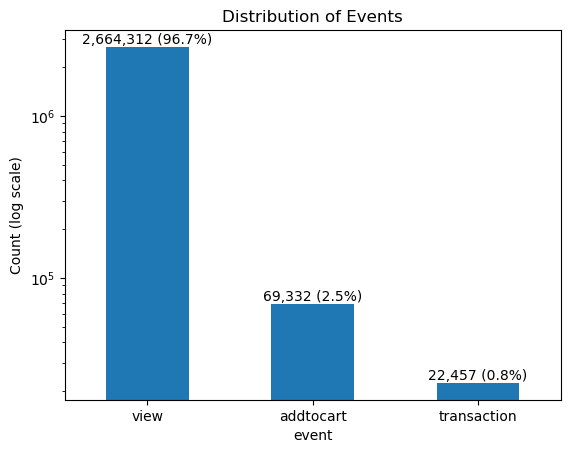

In [4]:
#Descriptive on the event types
counts = events_df.event.value_counts(sort=True, ascending=False)
total = counts.sum()
ax = counts.plot(kind='bar')
ax.set_yscale('log')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel("Count (log scale)",rotation=90)
ax.set_title("Distribution of Events")

for i,v in enumerate(counts):
    pct = v/total * 100
    ax.text(i, v, f"{v:,} ({pct:.1f}%)", ha='center', va='bottom')

In [5]:
# Which events have a transactionid?
events_df[events_df.transactionid.notnull()].event.unique()[0]

'transaction'

In [6]:
#Item properties - which are the most common properties?
item_properties_part1_df.property.value_counts(sort=True,ascending=False).head(5)

property
888           1629817
790            970800
available      817387
categoryid     426305
6              343207
Name: count, dtype: int64

In [8]:
# How many categories are there per parent category (Top 5)?
category_tree_df.groupby("parentid")["categoryid"].nunique().sort_values(ascending=False).reset_index(name="categories").head()

,parentid,categories
0,250.0,31
1,362.0,22
2,1009.0,22
3,351.0,19
4,1259.0,18


In [9]:
item_properties_part1_df.loc[(item_properties_part1_df.property == "categoryid") \
        &(item_properties_part1_df.value == '1016')].sort_values(by='timestamp', \
        ascending=True).head()

,timestamp,itemid,property,value
2105129,1431226800000,377283,categoryid,1016
970935,1431226800000,362999,categoryid,1016
3826363,1431226800000,373242,categoryid,1016
6363096,1431226800000,339403,categoryid,1016
4497603,1431226800000,390209,categoryid,1016


In [11]:
customers_who_purchased = events_df.loc[events_df.transactionid.notnull()].visitorid.unique()
print(f"Number of unique customers who made a purchase: {len(customers_who_purchased):,}")

Number of unique customers who made a purchase: 11,719


In [ ]:
#Repeat Users
visitors_with_transactions = events_df[events_df.transactionid.notnull()].groupby("visitorid")["transactionid"].nunique()

print(f"Repeat Users: {(visitors_with_transactions > 1).mean():.1%}")

Repeat Users: 9.1%
